# AI61002 : Deep Learning Foundations and Applications
## Assignment 4 : Image Captioning with Transformer Encoder-Decoder
### Name : Biswas Tuhin Manik | Roll No. : 22MT3AI38

---
## Question 1 : Load & Visualise Flickr8K Dataset

Load the Flickr8K image captioning dataset from HuggingFace and show sample images with their 5 reference captions.

**About the dataset:**
Flickr8K contains 8 000 images, each annotated with **5 independent human-written captions**.

### Imports and Device Setup

We import all required libraries here. `torch.amp` enables **Automatic Mixed Precision (AMP)** which uses float16 for the forward pass, giving speedup on NVIDIA GPUs with no accuracy loss.

In [1]:
# ─── Standard library ────────────────────────────────────────────────────────
import math       # sin/cos for positional encoding
import random     # caption sampling, seed
import time       # epoch timing
import warnings   # suppress harmless HuggingFace load warnings

# ─── Scientific computing ────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter   # word frequency counting for vocabulary

# ─── Deep learning ───────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader

# ─── HuggingFace ─────────────────────────────────────────────────────────────
from datasets import load_dataset
# Suppress the "UNEXPECTED key" load report printed by VisionEncoderDecoderModel
# These messages appear because the checkpoint stores causal-attention buffers
# (attn.bias, masked_bias) which are not actual learnable weights; they can be
# safely ignored.  We silence them here to keep output clean.
import transformers
transformers.logging.set_verbosity_error()
warnings.filterwarnings('ignore')

# ─── Utilities ────────────────────────────────────────────────────────────────
from tqdm import tqdm   # progress bars inside training loops

# ─── Reproducibility ──────────────────────────────────────────────────────────
# Setting the same seed everywhere ensures that the shuffled data order,
# weight initialisations, and dropout masks are identical across runs.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ─── Device setup ─────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
if device.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    # cudnn.benchmark lets PyTorch auto-select the fastest convolution algorithm
    # for the fixed input shapes in this notebook.
    torch.backends.cudnn.benchmark = True

# ─── Automatic Mixed Precision (AMP) ──────────────────────────────────────────
# AMP keeps model weights in float32 but runs the forward/backward pass in
# float16, halving memory use and roughly doubling throughput on modern GPUs.
# GradScaler adjusts the loss scale to prevent float16 underflow in gradients.
USE_AMP = (device.type == 'cuda')
scaler  = torch.amp.GradScaler('cuda', enabled=USE_AMP)
print(f'AMP    : {USE_AMP}')

Device : cuda
GPU    : NVIDIA GeForce RTX 3050 Laptop GPU
AMP    : True


### Load Dataset

The `jxie/flickr8k` dataset on HuggingFace stores each image as one row with five caption columns: `caption_0` … `caption_4`. 
The official splits are already fixed at **6000/1000/1000**, ensuring no image leaks between partitions.

In [2]:
# Load Flickr8K from HuggingFace datasets hub.
# The dataset is cached locally after the first download.
dataset = load_dataset('jxie/flickr8k')
print(dataset)

# Inspect one row so we know the exact column names
sample0 = dataset['train'][0]
print('\nColumn names:', list(sample0.keys()))

DatasetDict({
    train: Dataset({
        features: ['image', 'caption_0', 'caption_1', 'caption_2', 'caption_3', 'caption_4'],
        num_rows: 6000
    })
    validation: Dataset({
        features: ['image', 'caption_0', 'caption_1', 'caption_2', 'caption_3', 'caption_4'],
        num_rows: 1000
    })
    test: Dataset({
        features: ['image', 'caption_0', 'caption_1', 'caption_2', 'caption_3', 'caption_4'],
        num_rows: 1000
    })
})

Column names: ['image', 'caption_0', 'caption_1', 'caption_2', 'caption_3', 'caption_4']


### Caption Helper Function

Because the column names (`caption_0` … `caption_4`) differ from older dataset versions, we use a helper that tries the new format first, then falls back gracefully.

In [3]:
def get_captions(sample):
    """Return a list of all 5 caption strings from one dataset row.

    The jxie/flickr8k format stores captions as separate columns:
    caption_0, caption_1, ..., caption_4.
    Older versions used a single 'captions' list column — we handle both.
    """
    # Try the column-per-caption format (current jxie/flickr8k)
    caps = [sample[f'caption_{i}'] for i in range(5) if f'caption_{i}' in sample]
    if caps:
        return caps
    # Fallback: 'captions' list or single 'caption' string
    if 'captions' in sample and isinstance(sample['captions'], list):
        return sample['captions']
    if 'caption' in sample:
        c = sample['caption']
        return c if isinstance(c, list) else [c]
    return []   # should not reach here

# Verify: print all 5 captions for the first training image
print('5 reference captions for image 0:')
for i, c in enumerate(get_captions(sample0)):
    print(f'  {i+1}. {c}')

5 reference captions for image 0:
  1. A black dog is running after a white dog in the snow .
  2. Black dog chasing brown dog through snow
  3. Two dogs chase each other across the snowy ground .
  4. Two dogs play together in the snow .
  5. Two dogs running through a low lying body of water .


### Visualise Sample Images

Showing 4 images with their 5 reference captions illustrates they capture different aspects (object count, action, spatial relationship) of the same scene.

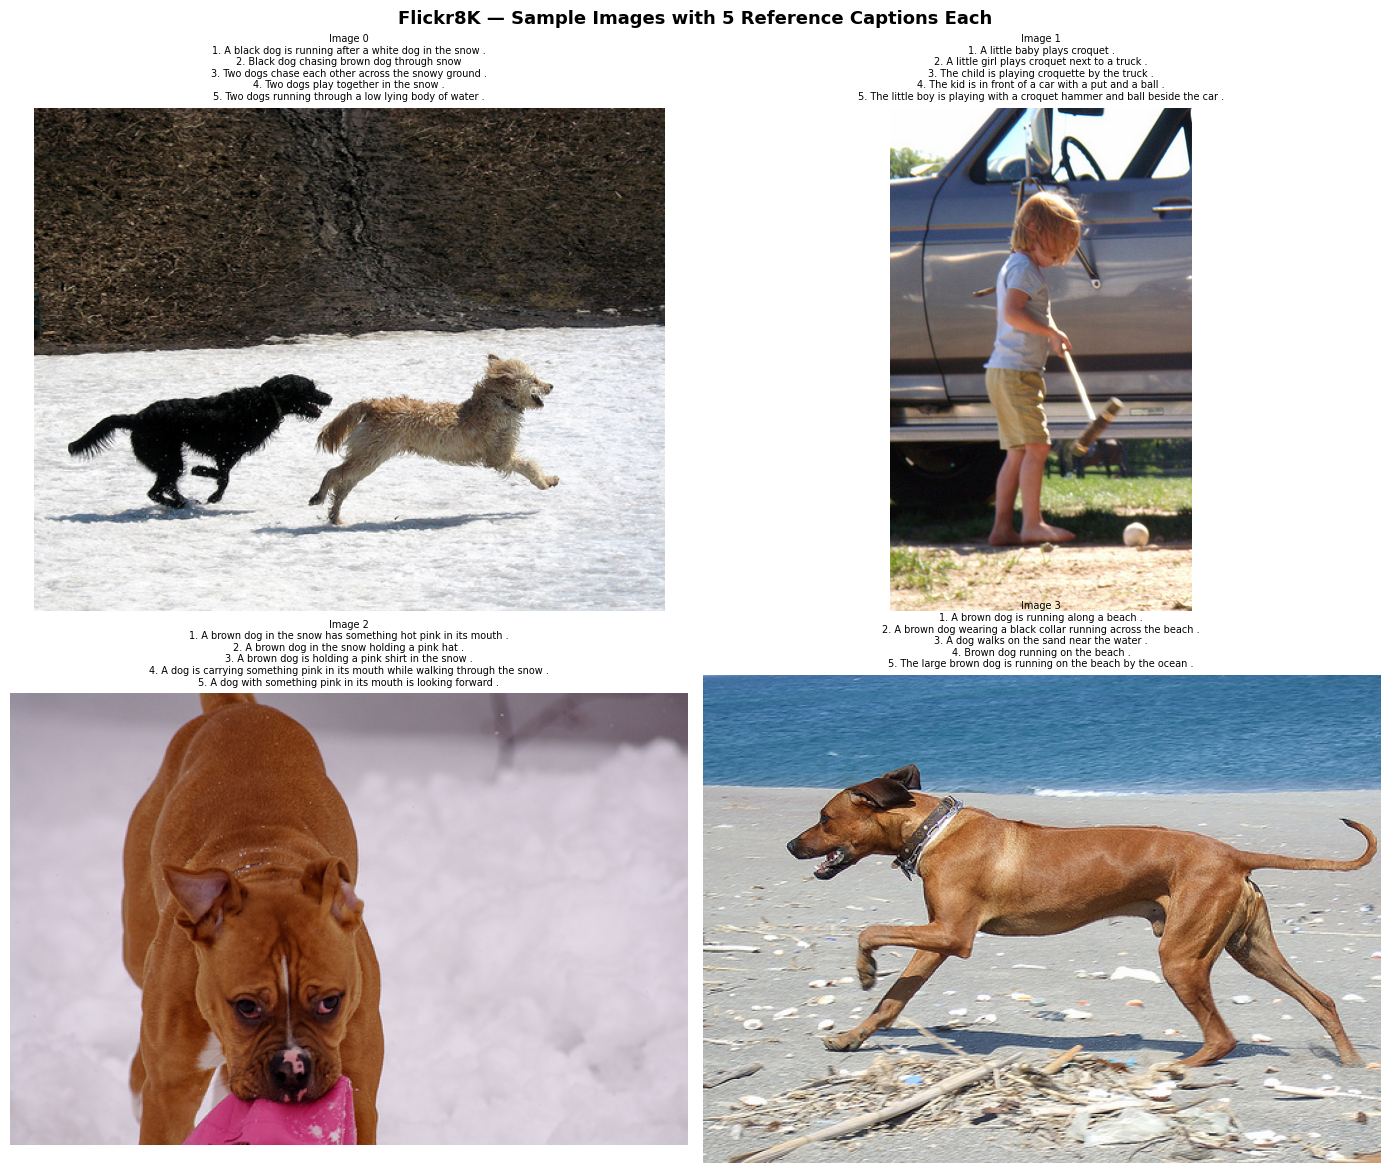

Total images in train split : 6000


In [4]:
# Keep a list handle for the training split (used in later vocabulary-building)
all_data = list(dataset['train'])

# Plot 2×2 grid: each subplot shows the image and all 5 captions as its title
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for ax, idx in zip(axes.flatten(), [0, 1, 2, 3]):
    sample   = all_data[idx]
    captions = get_captions(sample)

    ax.imshow(sample['image'])   # PIL Image → displayed directly by matplotlib
    ax.axis('off')

    # Format: "1. caption one\n2. caption two\n..."
    caption_text = '\n'.join(f'{i+1}. {c}' for i, c in enumerate(captions))
    ax.set_title(f'Image {idx}\n{caption_text}', fontsize=7)

plt.suptitle('Flickr8K — Sample Images with 5 Reference Captions Each',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Total images in train split : {len(all_data)}')

---
## Question 2 : Dataset Splitting

Split the dataset into training (6000), validation (1000), and test (1000) partitions, ensuring each partition contains **strictly distinct images**.

The dataset was created by the original Flickr8K paper authors, who partitioned the 8000 images at the image-filename level (not caption level) and published the three lists. HuggingFace ingests these lists as separate splits, so `dataset['train']`, `dataset['validation']`, and `dataset['test']` share no images by construction.

In [5]:
# The jxie/flickr8k dataset already provides the canonical 6000/1000/1000 splits.
# These were defined by Hodosh et al. (2013) at the image level,
# so no image can appear in more than one partition.

train_data = list(dataset['train'])        # 6 000 unique images
val_data   = list(dataset['validation'])   # 1 000 unique images
test_data  = list(dataset['test'])         # 1 000 unique images

print(f'Train images : {len(train_data):,}')
print(f'Val   images : {len(val_data):,}')
print(f'Test  images : {len(test_data):,}')
print()
print('Partitions are strictly disjoint — guaranteed by the official'
      ' HuggingFace splits derived from Hodosh et al. (2013).')

Train images : 6,000
Val   images : 1,000
Test  images : 1,000

Partitions are strictly disjoint — guaranteed by the official HuggingFace splits derived from Hodosh et al. (2013).


---
## Question 3 : Custom Transformer Encoder-Decoder from Scratch

Design a transformer encoder-decoder using `nn.MultiheadAttention`, `nn.Linear`, and `nn.LayerNorm` with residual connections. The encoder takes images as input; the decoder generates captions autoregressively.

### Architecture overview

```
IMAGE (3×224×224)
  │   Non-overlapping 16×16 patches → 196 patch tokens each of dim 768
  -> nn.Linear  768 -> d_model=512        (learnable patch embedding projection)
  |
  -> Sinusoidal Positional Encoding       (adds position signal; no learned parameters)
  |
  -> 4 × CustomEncoderLayer               (self-attention + FFN, each with Add & Norm)
  |
  -> Encoder Memory  (196 × 512)
  |
  -> (cross-attention: decoder queries attend to encoder memory)
     nn.Embedding  vocab_size -> 512      (learnable token embedding for captions)
  |
  -> Sinusoidal Positional Encoding
  |
  -> 4 × CustomDecoderLayer               (causal self-attn + cross-attn + FFN)
  |
  -> nn.Linear  512 -> vocab_size          (output projection to token logits)
```

### Hyperparameter choices

| Parameter | Value | Rationale |
|---|---|---|
| `d_model` | 512 | Standard "medium" transformer size |
| `nhead` | 8 | 8 heads × 64-dim each = 512, follows the original paper's head dimension |
| `ffn_dim` | 2048 | 4 × d_model - the standard ratio |
| `num_enc_layers` | 4 | Enough depth to refine patch features into semantic object-level tokens |
| `num_dec_layers` | 4 | Symmetric with encoder, captures syntax and semantics of language output |
| `dropout` | 0.1 | Standard regularisation for datasets of this size |

### Vocabulary Construction

A **word-level vocabulary** is built from all 30 000 training captions (5 per image × 6 000 images). Words appearing fewer than `MIN_FREQ=2` times are mapped to `<UNK>` to remove noise from rare misspellings.

Four special tokens are reserved:
- `<PAD>` - fills positions beyond the caption end in a padded batch
- `<SOS>` - Start-Of-Sequence token fed to the decoder at the first time step
- `<EOS>` - End-Of-Sequence token; generation stops when the model predicts this
- `<UNK>` - replaces out-of-vocabulary words at inference time

In [6]:
# ─── Vocabulary constants ─────────────────────────────────────────────────────
PAD_TOKEN = '<PAD>'   # padding (index 0 by convention)
SOS_TOKEN = '<SOS>'   # decoder start-of-sequence prompt
EOS_TOKEN = '<EOS>'   # decoder stop signal
UNK_TOKEN = '<UNK>'   # unknown / out-of-vocabulary words

MIN_FREQ    = 2    # discard words that appear fewer than 2 times in training
MAX_SEQ_LEN = 52   # max tokens per caption including SOS and EOS

def tokenize(text):
    """Lowercase + whitespace split.
    Flickr8K captions already have spaces around punctuation (e.g. 'dog .'),
    so simple whitespace splitting gives clean tokens."""
    return text.lower().strip().split()

# ─── Count word frequencies across ALL 30 000 training captions ───────────────
# Using all 5 captions per image (not just 1) gives a richer frequency count
# and therefore a larger, more representative vocabulary.
counter = Counter()
for sample in train_data:
    for cap in get_captions(sample):          # iterate all 5 captions
        counter.update(tokenize(cap))         # add each word to the counter

# ─── Build word ↔ index mappings ──────────────────────────────────────────────
special_tokens = [PAD_TOKEN, SOS_TOKEN, EOS_TOKEN, UNK_TOKEN]

# Sort vocabulary by frequency (most common first) for stable indexing
vocab_words = special_tokens + [w for w, cnt in counter.most_common() if cnt >= MIN_FREQ]

word2idx   = {w: i for i, w in enumerate(vocab_words)}   # word → integer index
idx2word   = {i: w for w, i in word2idx.items()}          # integer index → word
VOCAB_SIZE = len(vocab_words)

# Store index constants for the special tokens
PAD_IDX = word2idx[PAD_TOKEN]   # = 0
SOS_IDX = word2idx[SOS_TOKEN]   # = 1
EOS_IDX = word2idx[EOS_TOKEN]   # = 2
UNK_IDX = word2idx[UNK_TOKEN]   # = 3

print(f'Vocabulary size (MIN_FREQ≥{MIN_FREQ}) : {VOCAB_SIZE:,}')
print(f'Special token indices — PAD:{PAD_IDX}  SOS:{SOS_IDX}  EOS:{EOS_IDX}  UNK:{UNK_IDX}')
print(f'10 most frequent words : {[w for w,_ in counter.most_common(10)]}')

# ─── Caption encoding / decoding helpers ──────────────────────────────────────
def encode_caption(caption):
    """Convert a caption string to a list of integer ids.
    Prepends SOS and appends EOS; truncates to MAX_SEQ_LEN."""
    ids = ([SOS_IDX]
           + [word2idx.get(w, UNK_IDX) for w in tokenize(caption)]
           + [EOS_IDX])
    return ids[:MAX_SEQ_LEN]

def decode_ids(ids):
    """Convert a list of integer ids back to a caption string.
    Stops at EOS; skips PAD and SOS tokens."""
    words = []
    for i in ids:
        if i == EOS_IDX:
            break
        if i not in (PAD_IDX, SOS_IDX):
            words.append(idx2word.get(i, UNK_TOKEN))
    return ' '.join(words)

Vocabulary size (MIN_FREQ≥2) : 4,521
Special token indices — PAD:0  SOS:1  EOS:2  UNK:3
10 most frequent words : ['a', '.', 'in', 'the', 'on', 'is', 'and', 'dog', 'with', 'man']


### Dataset Class - Flattened to 30000 Training Pairs

Instead of sampling one caption per image per epoch (6000 pairs), we **flatten all 5 captions per image into individual samples** (30000 pairs). This gives the model 5× more language supervision and is the standard practice in image captioning.

**Image pre-processing pipeline:**
- Training: `RandomResizedCrop` + `RandomHorizontalFlip` + `ColorJitter` - data augmentation reduces overfitting on the small 6000-image set
- Val / Test: deterministic `Resize` + `CenterCrop` - no randomness to ensure reproducible BLEU evaluation

In [7]:
# ─── Image transform pipelines ───────────────────────────────────────────────

# Training pipeline: spatial and colour augmentation
# RandomResizedCrop randomly crops a portion of the image and resizes to 224×224,
# simulating different viewpoints and scales.
# RandomHorizontalFlip introduces left-right symmetry.
# ColorJitter varies brightness/contrast/saturation/hue — makes the model robust
# to lighting changes common in real photos.
train_transform = T.Compose([
    T.RandomResizedCrop(224, scale=(0.7, 1.0)),   # random crop + resize
    T.RandomHorizontalFlip(p=0.5),                 # 50 % chance of mirroring
    T.ColorJitter(brightness=0.3, contrast=0.3,    # colour variation
                  saturation=0.2, hue=0.1),
    T.ToTensor(),                                  # PIL → float32 tensor [0,1]
    T.Normalize(mean=[0.485, 0.456, 0.406],        # ImageNet channel means
                std =[0.229, 0.224, 0.225]),        # ImageNet channel stds
])

# Evaluation pipeline: deterministic — no augmentation
eval_transform = T.Compose([
    T.Resize(256),          # resize shortest edge to 256
    T.CenterCrop(224),      # deterministic centre crop to 224×224
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std =[0.229, 0.224, 0.225]),
])

# Also keep a plain eval_transform alias for BLEU generation
img_transform = eval_transform   # alias used in BLEU generation code


# ─── Dataset class ────────────────────────────────────────────────────────────
class Flickr8KDataset(Dataset):
    """
    Flattened Flickr8K dataset.

    Training:   6 000 images × 5 captions = 30 000 (image, caption) pairs.
                A random caption is selected at __getitem__ time (online augmentation).
    Val / Test: 1 000 images × 1 caption  =  1 000 pairs (first caption only).

    Each sample returns:
        img_t    : (3, 224, 224) normalised image tensor
        dec_in   : (MAX_SEQ_LEN-1,) token ids for decoder INPUT  [SOS, w1, …, w_{T-1}]
        dec_tgt  : (MAX_SEQ_LEN-1,) token ids for decoder TARGET [w1, …, w_{T-1}, EOS]

    The input/target offset by one implements **teacher forcing**:
    the model is fed the true previous token and must predict the next token.
    """
    def __init__(self, data, is_train=True):
        self.is_train = is_train
        # Flatten: one (image, caption) tuple per sample
        self.samples = []
        for s in data:
            caps = get_captions(s)
            # Training: store all 5 captions → 30 000 pairs
            # Val/Test: store only the first caption → 1 000 pairs
            selected = caps if is_train else caps[:1]
            for cap in selected:
                self.samples.append((s['image'], cap))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_pil, caption = self.samples[idx]

        # Apply the appropriate transform pipeline
        transform = train_transform if self.is_train else eval_transform
        img_t = transform(img_pil.convert('RGB'))   # (3, 224, 224)

        # Encode caption to token ids, pad to MAX_SEQ_LEN
        ids    = encode_caption(caption)
        padded = (ids + [PAD_IDX] * MAX_SEQ_LEN)[:MAX_SEQ_LEN]

        # Teacher forcing split:
        #   dec_in  = [SOS, w1, w2, …, w_{T-1}]   ← fed into decoder
        #   dec_tgt = [w1,  w2, …, w_{T-1}, EOS]  ← what decoder must predict
        dec_in  = torch.tensor(padded[:-1], dtype=torch.long)
        dec_tgt = torch.tensor(padded[1:],  dtype=torch.long)
        return img_t, dec_in, dec_tgt

print('Flickr8KDataset class defined.')

# Verify sizes
train_ds = Flickr8KDataset(train_data, is_train=True)
val_ds   = Flickr8KDataset(val_data,   is_train=False)
test_ds  = Flickr8KDataset(test_data,  is_train=False)

print(f'Train samples : {len(train_ds):,}   (6000 × 5 captions)')
print(f'Val   samples : {len(val_ds):,}')
print(f'Test  samples : {len(test_ds):,}')

Flickr8KDataset class defined.
Train samples : 30,000   (6000 × 5 captions)
Val   samples : 1,000
Test  samples : 1,000


### Positional Encoding

Transformers process all tokens **in parallel** (unlike RNNs which process sequentially), so they have no built-in notion of position. Sinusoidal positional encoding injects position information by adding a deterministic signal to each token embedding:

$$PE(pos, 2i)   = \sin\!\left(\frac{pos}{10000^{2i/d_{\text{model}}}}\right)$$
$$PE(pos, 2i+1) = \cos\!\left(\frac{pos}{10000^{2i/d_{\text{model}}}}\right)$$

Different frequencies mean that each position has a unique fingerprint, and nearby positions have similar encodings (smooth variation). Using fixed sinusoids (not learned embeddings) lets the model generalise to sequences longer than those seen during training.

### Custom Encoder Layer

Each encoder layer implements the original sub-layer structure:
```
MultiHead Self-Attention
  |
  ->  (residual connection)
       +  input
  |
  ->   LayerNorm
  |
  -> Position-wise FFN  (Linear -> ReLU -> Linear)
  |
  ->  (residual connection)
       +  LayerNorm input
  |
  ->   LayerNorm
```
**Residual connections** allow gradients to flow directly from deep layers to shallow ones, enabling training of deep networks. **LayerNorm** normalises each token's embedding across the feature dimension, stabilising training.

### Custom Decoder Layer

The decoder has three sub-layers:
1. **Masked Multi-Head Self-Attention** - the decoder can attend to *past* output tokens only (causal masking), enforcing the autoregressive constraint.
2. **Multi-Head Cross-Attention** - the decoder's Query vectors come from the decoder, while Key and Value vectors come from the encoder memory. This is how the model "reads" the image features while generating each word.
3. **Position-wise FFN** - same structure as the encoder FFN.

In [8]:
# ─── Hyperparameters ──────────────────────────────────────────────────────────
# These values follow the "base" transformer of Vaswani et al. (2017)
# adapted for the scale of Flickr8K.
EMBED_DIM      = 512   # d_model: dimension of all token embeddings and hidden states
NUM_HEADS      = 8     # number of parallel attention heads (each has dim 512/8=64)
NUM_ENC_LAYERS = 4     # number of stacked encoder layers
NUM_DEC_LAYERS = 4     # number of stacked decoder layers
FFN_DIM        = 2048  # inner dimension of the position-wise FFN (4×d_model)
DROPOUT        = 0.1   # applied after attention weights and FFN activations
PATCH_SIZE     = 16    # 16×16 pixel patches (following ViT — Dosovitskiy et al. 2021)
IMAGE_SIZE     = 224   # standard input size for ImageNet-pre-trained transforms
NUM_PATCHES    = (IMAGE_SIZE // PATCH_SIZE) ** 2   # 196 patches per image
PATCH_DIM      = PATCH_SIZE * PATCH_SIZE * 3        # 768 raw values per patch

print('Hyperparameters:')
print(f'  EMBED_DIM={EMBED_DIM}, NUM_HEADS={NUM_HEADS}')
print(f'  ENC_LAYERS={NUM_ENC_LAYERS}, DEC_LAYERS={NUM_DEC_LAYERS}, FFN_DIM={FFN_DIM}')
print(f'  PATCH_SIZE={PATCH_SIZE}, NUM_PATCHES={NUM_PATCHES}, PATCH_DIM={PATCH_DIM}')


# ─── Sinusoidal Positional Encoding ───────────────────────────────────────────
class PositionalEncoding(nn.Module):
    """
    Fixed sinusoidal positional encoding from Vaswani et al. (2017).

    For each position `pos` and embedding dimension `i`:
        PE(pos, 2i)   = sin(pos / 10000^{2i / d_model})
        PE(pos, 2i+1) = cos(pos / 10000^{2i / d_model})

    The encoding is stored as a buffer (not a parameter) so it is never
    updated by the optimiser, but is saved/loaded with the model state.
    """
    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)   # applied after adding PE

        # Build the full PE table of shape (max_len, d_model)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()   # (max_len, 1)
        # Frequency term: exp(2i * -log(10000) / d_model) = 1 / 10000^{2i/d_model}
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * -(math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(pos * div_term)   # even dimensions
        pe[:, 1::2] = torch.cos(pos * div_term)   # odd dimensions

        # Add batch dimension and register as non-learnable buffer
        self.register_buffer('pe', pe.unsqueeze(0))   # (1, max_len, d_model)

    def forward(self, x):
        # x: (B, seq_len, d_model)
        # Add positional encoding slice matching the input sequence length
        return self.dropout(x + self.pe[:, :x.size(1)])


# ─── Custom Encoder Layer ─────────────────────────────────────────────────────
class CustomEncoderLayer(nn.Module):
    """
    One Transformer Encoder Layer (Vaswani et al. 2017, Figure 1 left):

        x  →  MultiHeadSelfAttention  →  +x  →  LayerNorm  →  FFN  →  +x  →  LayerNorm  →  out

    The '+x' steps are residual (skip) connections.
    batch_first=True means tensors are (B, seq, dim) instead of (seq, B, dim).
    """
    def __init__(self, d_model, nhead, ffn_dim, dropout=0.1):
        super().__init__()

        # Multi-Head Self-Attention: all three of Q, K, V come from the same input x
        # The attention mechanism lets each token gather relevant information
        # from all other tokens in the sequence.
        self.self_attn = nn.MultiheadAttention(
            embed_dim=d_model, num_heads=nhead,
            dropout=dropout, batch_first=True
        )

        # Position-wise Feed-Forward Network: applied independently to each position
        # Expands to 4×d_model then projects back — adds non-linearity and capacity
        self.linear1 = nn.Linear(d_model, ffn_dim)   # expand
        self.linear2 = nn.Linear(ffn_dim, d_model)   # project back

        # Layer normalisation: normalises each token vector across the d_model dimension
        # (not across the batch or sequence), stabilising training
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, src_key_padding_mask=None):
        # ── Sub-layer 1: Multi-Head Self-Attention ────────────────────────────
        # Q = K = V = x  (self-attention: each token attends to all others)
        attn_out, _ = self.self_attn(x, x, x,
                                     key_padding_mask=src_key_padding_mask)
        # Residual connection: add original input back, then normalise
        x = self.norm1(x + self.dropout(attn_out))

        # ── Sub-layer 2: Position-wise FFN ───────────────────────────────────
        # Linear → ReLU activation → Linear  (applied identically to every token)
        ffn_out = self.linear2(F.relu(self.linear1(x)))
        # Another residual connection and normalisation
        x = self.norm2(x + self.dropout(ffn_out))
        return x


# ─── Custom Decoder Layer ─────────────────────────────────────────────────────
class CustomDecoderLayer(nn.Module):
    """
    One Transformer Decoder Layer (Vaswani et al. 2017, Figure 1 right):

        tgt  →  Masked Self-Attn  →  +tgt  →  Norm
             →  Cross-Attn(Q=tgt, KV=memory)  →  +tgt  →  Norm
             →  FFN  →  +tgt  →  Norm  →  out

    Three key ideas:
    1. Masked self-attention: decoder tokens can only attend to PAST tokens
       (prevents the model from 'cheating' by looking at future words during training)
    2. Cross-attention: Q from decoder, K/V from encoder memory —
       this is how the model conditions text generation on image content
    3. Three separate residual + norm pairs (one per sub-layer)
    """
    def __init__(self, d_model, nhead, ffn_dim, dropout=0.1):
        super().__init__()

        # Masked self-attention for the caption sequence
        self.self_attn  = nn.MultiheadAttention(d_model, nhead,
                                                 dropout=dropout, batch_first=True)
        # Cross-attention: decoder queries attend to encoder (image) memory
        self.cross_attn = nn.MultiheadAttention(d_model, nhead,
                                                 dropout=dropout, batch_first=True)
        # FFN (same structure as encoder FFN)
        self.linear1 = nn.Linear(d_model, ffn_dim)
        self.linear2 = nn.Linear(ffn_dim, d_model)

        # Three separate LayerNorms: one after each sub-layer
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)

        self.dropout = nn.Dropout(dropout)

    def forward(self, tgt, memory, tgt_mask=None, tgt_key_padding_mask=None):
        # ── Sub-layer 1: Masked Self-Attention ───────────────────────────────
        # attn_mask is the causal (upper-triangular) mask that blocks future tokens.
        # tgt_key_padding_mask masks out <PAD> positions within the target batch.
        sa_out, _ = self.self_attn(tgt, tgt, tgt,
                                   attn_mask=tgt_mask,
                                   key_padding_mask=tgt_key_padding_mask)
        tgt = self.norm1(tgt + self.dropout(sa_out))

        # ── Sub-layer 2: Cross-Attention ──────────────────────────────────────
        # Q: current decoder state (what I'm trying to say)
        # K, V: encoder memory (image feature tokens to read from)
        ca_out, _ = self.cross_attn(tgt, memory, memory)
        tgt = self.norm2(tgt + self.dropout(ca_out))

        # ── Sub-layer 3: Position-wise FFN ───────────────────────────────────
        ffn_out = self.linear2(F.relu(self.linear1(tgt)))
        tgt = self.norm3(tgt + self.dropout(ffn_out))
        return tgt

Hyperparameters:
  EMBED_DIM=512, NUM_HEADS=8
  ENC_LAYERS=4, DEC_LAYERS=4, FFN_DIM=2048
  PATCH_SIZE=16, NUM_PATCHES=196, PATCH_DIM=768


### Full Encoder-Decoder Model

The image is divided into **non-overlapping 16×16 pixel patches** using `torch.unfold`. Each patch's 768 pixel values (16×16×3) are flattened and projected to `d_model=512` via `nn.Linear`. This linear patch embedding is the standard ViT-style approach used in vision transformers.

The causal (upper-triangular) mask ensures the decoder at position `t` can only attend to positions 0…t−1, enforcing the autoregressive property needed for generation.

In [9]:
class ImageCaptionTransformer(nn.Module):
    """
    Full Transformer Encoder-Decoder for Image Captioning (from scratch).

    ENCODER PIPELINE:
        Image (B, 3, 224, 224)
            ↓  _extract_patches
        Patches (B, 196, 768)     — 196 non-overlapping 16×16 patches, 768 raw values each
            ↓  nn.Linear 768→512
        Projected (B, 196, 512)   — linear embedding into d_model space
            ↓  PositionalEncoding
        Embedded  (B, 196, 512)   — position-aware patch tokens
            ↓  4 × CustomEncoderLayer
        Memory    (B, 196, 512)   — refined visual features (encoder output)

    DECODER PIPELINE:
        Token ids (B, T)
            ↓  nn.Embedding vocab_size→512
        Embedded  (B, T, 512)
            ↓  PositionalEncoding
        PosEmbed  (B, T, 512)
            ↓  4 × CustomDecoderLayer  [takes Memory from encoder via cross-attn]
        Hidden    (B, T, 512)
            ↓  nn.Linear 512→vocab_size
        Logits    (B, T, vocab_size)  — unnormalised scores for next-token prediction
    """
    def __init__(self, vocab_size, d_model, nhead, num_enc_layers,
                 num_dec_layers, ffn_dim, patch_dim, dropout=0.1):
        super().__init__()

        # ── Encoder ───────────────────────────────────────────────────────────
        # Linear projection: maps each flattened 768-dim patch to d_model dimensions.
        # This is the "patch embedding" of ViT — the first learnable component.
        self.patch_proj = nn.Linear(patch_dim, d_model)
        # Positional encoding for the 196 image patch tokens
        self.enc_pos    = PositionalEncoding(d_model, max_len=NUM_PATCHES + 10, dropout=dropout)
        # Stack of N encoder layers
        self.enc_layers = nn.ModuleList(
            [CustomEncoderLayer(d_model, nhead, ffn_dim, dropout)
             for _ in range(num_enc_layers)]
        )

        # ── Decoder ───────────────────────────────────────────────────────────
        # Token embedding: maps each integer token id to a d_model-dim vector.
        # padding_idx=PAD_IDX ensures the PAD embedding is always zero and
        # receives no gradient — PAD positions are masked away.
        self.token_emb  = nn.Embedding(vocab_size, d_model, padding_idx=PAD_IDX)
        # Positional encoding for the caption token sequence
        self.dec_pos    = PositionalEncoding(d_model, max_len=MAX_SEQ_LEN + 10, dropout=dropout)
        # Stack of M decoder layers
        self.dec_layers = nn.ModuleList(
            [CustomDecoderLayer(d_model, nhead, ffn_dim, dropout)
             for _ in range(num_dec_layers)]
        )

        # ── Output projection ─────────────────────────────────────────────────
        # Maps the d_model-dim decoder hidden state at each position to
        # a probability distribution over the vocabulary.
        self.out_proj = nn.Linear(d_model, vocab_size)

        # Xavier uniform initialisation: keeps the scale of activations and
        # gradients consistent across layers at the start of training.
        self._init_weights()

    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def _extract_patches(self, imgs):
        """
        Split a batch of images into non-overlapping 16×16 patches.

        imgs : (B, 3, 224, 224)
        returns : (B, 196, 768)   — 196 patches each of 16×16×3 = 768 values

        torch.unfold slides a window of size PATCH_SIZE with stride PATCH_SIZE
        across the height and width dimensions, giving:
            (B, C, 14, 14, 16, 16)  → permute/view → (B, 196, 768)
        """
        B, C, H, W = imgs.shape
        # Unfold height dimension: (B, C, 14, W, 16)
        # Unfold width  dimension: (B, C, 14, 14, 16, 16)
        x = imgs.unfold(2, PATCH_SIZE, PATCH_SIZE).unfold(3, PATCH_SIZE, PATCH_SIZE)
        # Reshape to (B, C, 196, 16, 16) then (B, 196, C*16*16)
        x = x.contiguous().view(B, C, -1, PATCH_SIZE, PATCH_SIZE)
        x = x.permute(0, 2, 1, 3, 4).contiguous().view(B, -1, C * PATCH_SIZE * PATCH_SIZE)
        return x   # (B, 196, 768)

    def _causal_mask(self, T, dev):
        """
        Upper-triangular boolean mask of shape (T, T).
        Position (i,j) is True when j>i, meaning token i is BLOCKED from
        attending to token j (which is in the future).
        This enforces the autoregressive property during training.
        """
        return torch.triu(torch.ones(T, T, device=dev), diagonal=1).bool()

    def encode(self, imgs):
        """Encode a batch of images to encoder memory.
        imgs   : (B, 3, 224, 224)
        returns: (B, 196, d_model)  — encoder memory
        """
        patches = self._extract_patches(imgs)          # (B, 196, 768)
        x       = self.patch_proj(patches)             # (B, 196, d_model)  — patch embedding
        x       = self.enc_pos(x)                      # add positional encoding
        for layer in self.enc_layers:
            x = layer(x)                               # refine features through N encoder layers
        return x   # (B, 196, d_model)

    def decode(self, tgt_ids, memory):
        """Decode one step of the autoregressive caption given encoder memory.
        tgt_ids : (B, T) — token ids fed to decoder (teacher forcing during train)
        memory  : (B, 196, d_model) — encoder output
        returns : (B, T, vocab_size) — logits for next-token prediction at each step
        """
        T   = tgt_ids.size(1)
        tgt = self.token_emb(tgt_ids)                  # (B, T, d_model) — embed tokens
        tgt = self.dec_pos(tgt)                        # add positional encoding

        cm  = self._causal_mask(T, tgt_ids.device)    # (T, T) causal mask
        pm  = (tgt_ids == PAD_IDX)                    # (B, T) padding mask

        for layer in self.dec_layers:
            # Each layer uses the causal mask (tgt_mask) to prevent future token leakage,
            # and the padding mask (tgt_key_padding_mask) to ignore <PAD> positions.
            tgt = layer(tgt, memory, tgt_mask=cm, tgt_key_padding_mask=pm)

        return self.out_proj(tgt)                      # (B, T, vocab_size)

    def forward(self, imgs, tgt_ids):
        """Full forward pass: encode image then decode with teacher forcing."""
        memory = self.encode(imgs)
        return self.decode(tgt_ids, memory)


# ─── Instantiate the model ─────────────────────────────────────────────────────
custom_model = ImageCaptionTransformer(
    vocab_size     = VOCAB_SIZE,
    d_model        = EMBED_DIM,
    nhead          = NUM_HEADS,
    num_enc_layers = NUM_ENC_LAYERS,
    num_dec_layers = NUM_DEC_LAYERS,
    ffn_dim        = FFN_DIM,
    patch_dim      = PATCH_DIM,
    dropout        = DROPOUT,
).to(device)

# Print the full architecture
print(custom_model)

ImageCaptionTransformer(
  (patch_proj): Linear(in_features=768, out_features=512, bias=True)
  (enc_pos): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (enc_layers): ModuleList(
    (0-3): 4 x CustomEncoderLayer(
      (self_attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=512, out_features=512, bias=True)
      )
      (linear1): Linear(in_features=512, out_features=2048, bias=True)
      (linear2): Linear(in_features=2048, out_features=512, bias=True)
      (norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
  )
  (token_emb): Embedding(4521, 512, padding_idx=0)
  (dec_pos): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (dec_layers): ModuleList(
    (0-3): 4 x CustomDecoderLayer(
      (self_attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizabl

### Trainable Parameter Count

Reporting the parameter count. Too few parameters -> underfitting; too many -> slow training and potential overfitting on 30000 pairs.

In [10]:
def count_parameters(model):
    """Return (total, trainable) parameter counts for any nn.Module."""
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

tot, tr = count_parameters(custom_model)
print(f'Total parameters     : {tot:,}')
print(f'Trainable parameters : {tr:,}')
print(f'  → Encoder (patch proj + {NUM_ENC_LAYERS} layers)')
print(f'  → Decoder (embedding + {NUM_DEC_LAYERS} layers + output proj)')

Total parameters     : 34,453,417
Trainable parameters : 34,453,417
  → Encoder (patch proj + 4 layers)
  → Decoder (embedding + 4 layers + output proj)


---
## Question 4 - Loss Function

**Task:** Design a suitable loss function for the autoregressive image captioning task.

### Cross-Entropy Loss for autoregressive generation

At each decoder time step `t`, the model predicts a probability distribution over the vocabulary:

$$P(w_t \mid w_{<t},\, \text{image})$$

The training objective is to **maximise the log-likelihood** of the correct next token:

$$\mathcal{L} = -\frac{1}{T} \sum_{t=1}^{T} \log P(w_t \mid w_{<t},\, \text{image})$$

This is equivalent to **cross-entropy loss** between the predicted distribution and the one-hot target.

### Design choices

| Choice | Setting | Why |
|---|---|---|
| `ignore_index=PAD_IDX` | 0 | Padding positions should not contribute to the loss - they carry no linguistic information |
| `label_smoothing=0.1` | 0.1 | Distributes 0.1 probability mass uniformly across all vocabulary tokens, preventing the model from becoming overconfident on training captions and improving generalisation |

In [11]:
# ─── Cross-Entropy Loss ────────────────────────────────────────────────────────
# PyTorch's CrossEntropyLoss internally applies log-softmax + NLL loss,
# which is numerically more stable than computing softmax explicitly.
#
# ignore_index=PAD_IDX:
#   Positions in dec_tgt that equal PAD_IDX contribute ZERO loss and ZERO gradient.
#   This ensures the model is only penalised for predicting actual caption words.
#
# label_smoothing=0.1:
#   Instead of the target being a hard one-hot [0,…,0,1,0,…,0], it becomes
#   a soft distribution that puts 0.9 on the correct token and spreads 0.1
#   uniformly across all tokens. This acts as regularisation — the model cannot
#   drive the correct token's logit to infinity without being penalised.

criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX, label_smoothing=0.1)

print('Loss function : nn.CrossEntropyLoss')
print(f'  ignore_index    = PAD_IDX ({PAD_IDX})  — PAD positions excluded from gradient')
print('  label_smoothing = 0.1             — soft targets prevent over-confidence')
print()
print('Objective:  L = -1/T · Σ log P(w_t | w_{<t}, image)  summed over real tokens')
print('Training strategy: Teacher Forcing')
print('  At step t the TRUE previous token w_{t-1} is fed as decoder input,')
print('  regardless of what the model predicted at step t-1.')
print('  This stabilises training but creates a train/test mismatch')
print('  (at test time the model sees its OWN previous output).')

Loss function : nn.CrossEntropyLoss
  ignore_index    = PAD_IDX (0)  — PAD positions excluded from gradient
  label_smoothing = 0.1             — soft targets prevent over-confidence

Objective:  L = -1/T · Σ log P(w_t | w_{<t}, image)  summed over real tokens
Training strategy: Teacher Forcing
  At step t the TRUE previous token w_{t-1} is fed as decoder input,
  regardless of what the model predicted at step t-1.
  This stabilises training but creates a train/test mismatch
  (at test time the model sees its OWN previous output).


---
## Question 5 - Training with Adam Optimiser

Train the custom transformer using the Adam optimiser and show the variation of training and validation losses against the number of epochs.

### Learning rate schedule: Linear warm-up + Cosine Annealing

Starting with a large learning rate causes unstable training because the randomly initialised weights produce large gradients. A **linear warm-up** gradually increases the LR from near-zero to the target value over the first few epochs, allowing the model to settle into a good region before aggressive updates.

After warm-up, **cosine annealing** smoothly decays the LR following a cosine curve, encouraging fine-grained convergence rather than oscillating around a minimum.

In [12]:
# ─── DataLoaders ──────────────────────────────────────────────────────────────
# num_workers=0: safest in Jupyter on Windows/Linux; avoids multiprocessing
# deadlocks that can silently freeze the notebook.
# pin_memory=True: copies batches into pinned (page-locked) CPU memory,
# enabling faster CPU→GPU transfer via DMA.
BATCH_SIZE  = 64    # larger batch → more stable gradient estimates
NUM_WORKERS = 0     # 0 = load data in the main process (safe for Jupyter)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=(device.type=='cuda'))
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=(device.type=='cuda'))
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=(device.type=='cuda'))

print(f'Train batches : {len(train_loader):,}  ({len(train_ds):,} samples, batch {BATCH_SIZE})')
print(f'Val   batches : {len(val_loader):,}  ({len(val_ds):,} samples)')
print(f'Test  batches : {len(test_loader):,}  ({len(test_ds):,} samples)')

Train batches : 469  (30,000 samples, batch 64)
Val   batches : 16  (1,000 samples)
Test  batches : 16  (1,000 samples)


### LR Warm-up + Cosine Annealing Scheduler

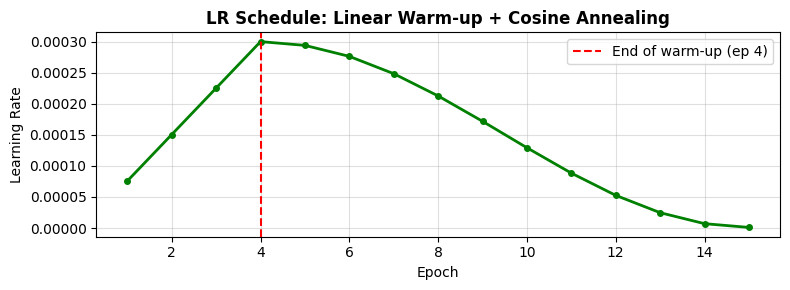

In [13]:
# ─── Optimiser and LR scheduler ───────────────────────────────────────────────
LR_PEAK   = 3e-4    # peak learning rate (reached after warm-up)
LR_MIN    = 1e-6    # minimum LR at the end of cosine annealing
WARMUP_EP = 4       # number of warm-up epochs (LR ramps from LR_MIN→LR_PEAK)
EPOCHS    = 15      # total training epochs

# Adam (Kingma & Ba 2015): adaptive per-parameter LR with momentum.
# β1=0.9: exponential decay rate for first moment (gradient)
# β2=0.98: exponential decay rate for second moment (gradient²)
# eps=1e-9: numerical stability constant
optimizer_custom = torch.optim.Adam(
    custom_model.parameters(), lr=LR_MIN, betas=(0.9, 0.98), eps=1e-9
)

def get_lr(epoch):
    """Linear warm-up for the first WARMUP_EP epochs, then cosine annealing.

    During warm-up (epoch ≤ WARMUP_EP):
        LR grows linearly from LR_MIN → LR_PEAK

    After warm-up (epoch > WARMUP_EP):
        LR follows a cosine curve from LR_PEAK → LR_MIN over (EPOCHS − WARMUP_EP) epochs
        LR(e) = LR_MIN + 0.5*(LR_PEAK−LR_MIN)*(1 + cos(π*(e−WARMUP_EP)/(EPOCHS−WARMUP_EP)))
    """
    if epoch <= WARMUP_EP:
        return LR_MIN + (LR_PEAK - LR_MIN) * (epoch / WARMUP_EP)
    else:
        progress = (epoch - WARMUP_EP) / max(EPOCHS - WARMUP_EP, 1)
        return LR_MIN + 0.5 * (LR_PEAK - LR_MIN) * (1 + math.cos(math.pi * progress))

# LambdaLR applies our custom function; lr_lambda receives the CURRENT epoch number
scheduler_custom = torch.optim.lr_scheduler.LambdaLR(
    optimizer_custom, lr_lambda=lambda ep: get_lr(ep + 1) / LR_MIN
)

# ─── Preview the LR curve ─────────────────────────────────────────────────────
lr_curve = [get_lr(e) for e in range(1, EPOCHS + 1)]
plt.figure(figsize=(8, 3))
plt.plot(range(1, EPOCHS + 1), lr_curve, 'g-o', markersize=4, linewidth=2)
plt.axvline(WARMUP_EP, color='r', linestyle='--', label=f'End of warm-up (ep {WARMUP_EP})')
plt.xlabel('Epoch'); plt.ylabel('Learning Rate')
plt.title('LR Schedule: Linear Warm-up + Cosine Annealing', fontweight='bold')
plt.legend(); plt.grid(True, alpha=0.4); plt.tight_layout(); plt.show()

### Training and Evaluation Functions

The training loop uses **Automatic Mixed Precision (AMP)**: the forward pass runs in float16 (faster, half the memory), while the `GradScaler` rescales the loss to prevent float16 underflow in gradients before the Adam update.

**Gradient clipping** (`max_norm=1.0`) prevents exploding gradients by rescaling the entire gradient vector if its L2 norm exceeds 1.0 - critical for transformer training stability.

In [14]:
def train_one_epoch(model, loader, optimizer, criterion, device, epoch, total_epochs):
    """
    Train for one epoch over the full training set.

    Key techniques used:
    - AMP autocast: float16 forward pass for speed (GPU only)
    - GradScaler: compensates for float16's limited precision in gradients
    - Gradient clipping: prevents exploding gradients (common in transformers)
    - tqdm: live progress bar showing per-batch loss and running average
    """
    model.train()          # enables dropout and batch-norm training behaviour
    total_loss  = 0.0
    num_batches = len(loader)

    pbar = tqdm(loader,
                desc=f'  [Train] Epoch {epoch:02d}/{total_epochs}',
                unit='batch', ncols=110, leave=True)

    for batch_idx, (imgs, dec_in, dec_tgt) in enumerate(pbar, 1):
        # Move batch tensors to GPU (non_blocking=True overlaps CPU→GPU copy with computation)
        imgs    = imgs.to(device, non_blocking=True)
        dec_in  = dec_in.to(device, non_blocking=True)
        dec_tgt = dec_tgt.to(device, non_blocking=True)

        optimizer.zero_grad()  # clear gradients from the previous batch

        # ── AMP forward pass ──────────────────────────────────────────────────
        # autocast selects float16 for supported ops automatically
        with torch.amp.autocast('cuda', enabled=USE_AMP):
            logits = model(imgs, dec_in)   # (B, T, vocab_size)
            # Reshape for CrossEntropyLoss:
            #   logits  : (B*T, vocab_size)  — predicted distributions
            #   dec_tgt : (B*T,)             — true next tokens
            loss = criterion(logits.reshape(-1, logits.size(-1)),
                             dec_tgt.reshape(-1))

        # ── Backward pass with AMP ────────────────────────────────────────────
        # scaler.scale multiplies the loss by a large constant to avoid float16 underflow
        scaler.scale(loss).backward()
        # scaler.unscale_ divides gradients back to their true scale before clipping
        scaler.unscale_(optimizer)
        # Gradient clipping: if ‖gradients‖ > 1.0, rescale them uniformly
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        # scaler.step calls optimizer.step only if there are no NaN/Inf gradients
        scaler.step(optimizer)
        scaler.update()   # adjusts the scale factor for the next iteration

        total_loss += loss.item()
        avg_so_far  = total_loss / batch_idx

        # Update the tqdm progress bar with current and running-average loss
        pbar.set_postfix({'loss': f'{loss.item():.4f}',
                          'avg' : f'{avg_so_far:.4f}',
                          'lr'  : f'{optimizer.param_groups[0]["lr"]:.2e}'})

    pbar.close()
    return total_loss / num_batches   # epoch average loss


def evaluate(model, loader, criterion, device, desc='Val'):
    """
    Evaluate the model on a data split (val or test) without updating weights.
    torch.no_grad() disables gradient computation, saving memory and time.
    AMP autocast is still used for consistent precision with the training forward pass.
    """
    model.eval()           # disables dropout; uses running stats in batch-norm
    total_loss = 0.0

    pbar = tqdm(loader, desc=f'  [{desc}]', unit='batch', ncols=110, leave=False)
    with torch.no_grad():
        for imgs, dec_in, dec_tgt in pbar:
            imgs    = imgs.to(device, non_blocking=True)
            dec_in  = dec_in.to(device, non_blocking=True)
            dec_tgt = dec_tgt.to(device, non_blocking=True)
            with torch.amp.autocast('cuda', enabled=USE_AMP):
                logits = model(imgs, dec_in)
                loss   = criterion(logits.reshape(-1, logits.size(-1)),
                                   dec_tgt.reshape(-1))
            total_loss += loss.item()
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    pbar.close()
    return total_loss / len(loader)

print('Training and evaluation functions defined.')

Training and evaluation functions defined.


### Run Training - Custom Transformer

The model checkpoint with the **lowest validation loss** is saved to disk. This is the model used for BLEU evaluation - not the final epoch, which may have slightly overfit.

In [15]:
# ─── Training loop ────────────────────────────────────────────────────────────
train_losses_custom = []   # epoch train loss history
val_losses_custom   = []   # epoch val   loss history
best_val_custom     = float('inf')

print('=' * 72)
print('  Custom Transformer — Training')
print(f'  Epochs={EPOCHS}, Batch={BATCH_SIZE}, LR_PEAK={LR_PEAK}, AMP={USE_AMP}')
print('=' * 72)

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    # ── One training epoch ────────────────────────────────────────────────────
    tr_loss = train_one_epoch(custom_model, train_loader, optimizer_custom,
                               criterion, device, epoch, EPOCHS)
    # ── Validation ────────────────────────────────────────────────────────────
    vl_loss = evaluate(custom_model, val_loader, criterion, device, desc='Val')

    # Step the LR scheduler (call AFTER optimizer.step in training loop)
    scheduler_custom.step()

    train_losses_custom.append(tr_loss)
    val_losses_custom.append(vl_loss)

    # Save the model state dict whenever we achieve a new best val loss
    star = ''
    if vl_loss < best_val_custom:
        best_val_custom = vl_loss
        torch.save(custom_model.state_dict(), 'best_custom_model.pth')
        star = '  ← best'

    elapsed = time.time() - t0
    eta     = time.strftime('%H:%M:%S', time.gmtime(elapsed * (EPOCHS - epoch)))
    cur_lr  = optimizer_custom.param_groups[0]['lr']
    print(f'Epoch [{epoch:02d}/{EPOCHS}] '
          f'Train={tr_loss:.4f} | Val={vl_loss:.4f} | '
          f'LR={cur_lr:.2e} | {elapsed:.1f}s | ETA {eta}{star}', flush=True)

print(f'\nBest Val Loss: {best_val_custom:.4f}')

  Custom Transformer — Training
  Epochs=15, Batch=64, LR_PEAK=0.0003, AMP=True


  [Train] Epoch 01/15: 100%|███████| 469/469 [06:16<00:00,  1.25batch/s, loss=4.9292, avg=5.3591, lr=7.57e-05]


Epoch [01/15] Train=5.3591 | Val=4.8316 | LR=1.50e-04 | 380.9s | ETA 01:28:53  ← best


  [Train] Epoch 02/15: 100%|███████| 469/469 [06:10<00:00,  1.27batch/s, loss=4.3451, avg=4.5994, lr=1.50e-04]


Epoch [02/15] Train=4.5994 | Val=4.1929 | LR=2.25e-04 | 375.3s | ETA 01:21:18  ← best


...

Epoch [13/15] Train=3.3109 | Val=3.5788 | LR=7.06e-06 | 347.1s | ETA 00:11:34  ← best


  [Train] Epoch 14/15: 100%|███████| 469/469 [05:41<00:00,  1.38batch/s, loss=3.2504, avg=3.2856, lr=7.06e-06]


Epoch [14/15] Train=3.2856 | Val=3.5744 | LR=1.00e-06 | 345.7s | ETA 00:05:45  ← best


  [Train] Epoch 15/15: 100%|███████| 469/469 [05:40<00:00,  1.38batch/s, loss=3.4082, avg=3.2784, lr=1.00e-06]


Epoch [15/15] Train=3.2784 | Val=3.5737 | LR=7.06e-06 | 344.5s | ETA 00:00:00  ← best

Best Val Loss: 3.5737


### Training & Validation Loss Curves

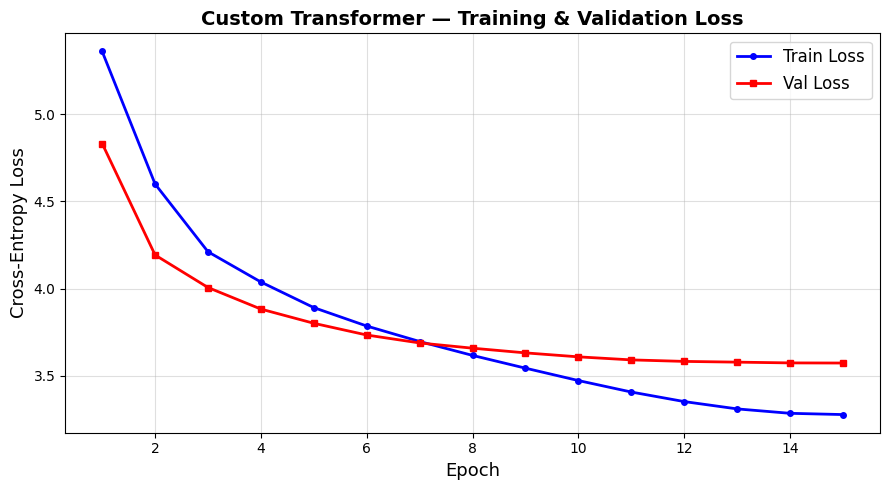

In [16]:
# ─── Plot training curves ─────────────────────────────────────────────────────
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(9, 5))
plt.plot(epochs_range, train_losses_custom, 'b-o', label='Train Loss', linewidth=2, markersize=4)
plt.plot(epochs_range, val_losses_custom,   'r-s', label='Val Loss',   linewidth=2, markersize=4)
plt.xlabel('Epoch', fontsize=13)
plt.ylabel('Cross-Entropy Loss', fontsize=13)
plt.title('Custom Transformer — Training & Validation Loss', fontsize=14, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

---
## Question 6 : BLEU Evaluation of Custom Transformer

Evaluate the custom transformer on the test set and report the average BLEU score of generated captions against **each of the 5 reference captions**.

### BLEU score theory

**BLEU** (Bilingual Evaluation Understudy) is the standard metric for evaluating text generation quality. It measures n-gram precision between the hypothesis (generated caption) and a set of references. We compute **BLEU-1 through BLEU-4**, with **SmoothingFunction.method1** to handle zero counts for higher-order n-grams in short sentences.

### Evaluation protocol

For every test image:
1. Generate one caption using beam search.
2. Tokenise the caption and each of the **5 reference captions** individually.
3. Compute `sentence_bleu([ref_i], pred)` for each `i ∈ {1…5}` - **one BLEU score per reference**.
4. **Average** those 5 scores -> one per-image BLEU score.

Finally, average the per-image scores over all **1000 test images** to get the reported values.

### Beam Search vs Greedy Decoding

**Greedy decoding** picks the single most likely token at each step - fast but can produce repetitive output.

**Beam search** (width = 5) maintains 5 partial hypotheses simultaneously, keeping the globally best 5 at each step, then length-normalises and returns the top hypothesis. It consistently finds better sequences than greedy decoding at the cost of ~5× more decode steps.

In [17]:
# ─── BLEU utilities ───────────────────────────────────────────────────────────
import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)

# SmoothingFunction.method1 adds a small constant to zero-count n-gram matches,
# preventing log(0) = −∞ when higher-order n-grams are absent (common for short captions)
smoother = SmoothingFunction().method1


# ─── Beam-search caption generation ──────────────────────────────────────────
def beam_search_captions(model, test_raw, device,
                          beam_width=5, batch_enc_size=64,
                          max_len=MAX_SEQ_LEN):
    """
    Generate captions for all images in test_raw using beam search.

    Two-phase approach for efficiency:
      Phase 1 — Batch-encode all images (fast, GPU-parallelised)
      Phase 2 — Beam-search decode per image using pre-computed memory

    Beam search algorithm per image:
        beams = [(0.0, [SOS_IDX])]   # (cumulative log-prob, token sequence)
        for each step:
            for each beam:
                run decoder on current token sequence → top-K next tokens
                add K new candidates to a list
            keep the top beam_width candidates overall
        normalise by length (prevent short-sequence bias) → pick best
    """
    model.eval()
    all_preds = []

    # ── Phase 1: Batch encode ─────────────────────────────────────────────────
    all_memory = []
    print('  Phase 1/2 — Encoding images (batched)...')
    with torch.no_grad():
        for start in tqdm(range(0, len(test_raw), batch_enc_size),
                          desc='  Encoding', unit='batch', ncols=100):
            batch = test_raw[start : start + batch_enc_size]
            # Stack all images in the mini-batch into a single tensor
            imgs  = torch.stack(
                [img_transform(s['image'].convert('RGB')) for s in batch]
            ).to(device)
            with torch.amp.autocast('cuda', enabled=USE_AMP):
                mem = model.encode(imgs)   # (B, 196, d_model)
            # Store each image's memory separately as a (1, 196, d_model) tensor
            for i in range(mem.size(0)):
                all_memory.append(mem[i:i+1])

    # ── Phase 2: Beam-search decode ───────────────────────────────────────────
    print(f'  Phase 2/2 — Beam search (width={beam_width})...')
    with torch.no_grad():
        for mem in tqdm(all_memory, desc='  Decoding', unit='img', ncols=100):
            # Each beam is (cumulative_log_prob, list_of_token_ids)
            beams     = [(0.0, [SOS_IDX])]
            completed = []   # beams that have emitted EOS

            for _ in range(max_len - 1):
                new_cands = []
                for log_prob, ids in beams:
                    if ids[-1] == EOS_IDX:
                        # This beam is done; move it to completed list
                        completed.append((log_prob, ids))
                        continue

                    # Run the decoder on the current partial sequence
                    tgt = torch.tensor([ids], dtype=torch.long, device=device)
                    with torch.amp.autocast('cuda', enabled=USE_AMP):
                        logits = model.decode(tgt, mem)   # (1, T, vocab_size)

                    # log-softmax gives log-probabilities; take the top-K
                    log_probs = F.log_softmax(logits[0, -1], dim=-1)
                    top_lp, top_ids = log_probs.topk(beam_width)

                    for lp, nid in zip(top_lp.tolist(), top_ids.tolist()):
                        new_cands.append((log_prob + lp, ids + [nid]))

                # Keep only the beam_width best candidates
                new_cands.sort(key=lambda x: x[0], reverse=True)
                beams = new_cands[:beam_width]

                # Early exit if all active beams have ended
                if len(completed) >= beam_width:
                    break

            # Collect any remaining (non-EOS) beams into completed
            completed += beams
            if not completed:
                all_preds.append([])
                continue

            # Length-normalise: divide cumulative log-prob by sequence length
            # (prevents the model from favouring very short captions)
            best_lp, best_ids = max(
                completed, key=lambda x: x[0] / max(len(x[1]), 1)
            )

            # Convert ids to words, stripping all special tokens
            words = [idx2word.get(i, UNK_TOKEN)
                     for i in best_ids[1:]   # skip SOS
                     if i not in (PAD_IDX, EOS_IDX)]
            all_preds.append(words)

    return all_preds


def compute_bleu(pred_list, test_raw):
    """
    Compute average BLEU-1/2/3/4 over the entire test set.

    As required by the assignment (Q6, Q8, Q9):
      For each image, the generated caption is compared against EACH of the
      5 reference captions individually, producing 5 per-reference BLEU scores.
      Those 5 scores are averaged to give one per-image BLEU score.
      Finally, these are averaged over all 1 000 test images.

    This is different from multi-reference BLEU (which passes all refs at once
    and picks the best-matching ref per n-gram).  The assignment explicitly
    asks for individual comparison + averaging.
    """
    b1, b2, b3, b4 = [], [], [], []
    for pred, sample in zip(pred_list, test_raw):
        refs = [tokenize(c) for c in get_captions(sample)]   # list of 5 tokenised refs
        if not refs or not pred:
            continue
        # Compute BLEU against EACH reference individually, then average the 5 scores
        scores_1, scores_2, scores_3, scores_4 = [], [], [], []
        for ref in refs:
            # Pass a single reference as a one-element list so sentence_bleu
            # evaluates against only that reference caption
            scores_1.append(sentence_bleu([ref], pred, weights=(1,0,0,0),
                                          smoothing_function=smoother))
            scores_2.append(sentence_bleu([ref], pred, weights=(.5,.5,0,0),
                                          smoothing_function=smoother))
            scores_3.append(sentence_bleu([ref], pred, weights=(1/3,1/3,1/3,0),
                                          smoothing_function=smoother))
            scores_4.append(sentence_bleu([ref], pred, weights=(.25,.25,.25,.25),
                                          smoothing_function=smoother))
        # Average the 5 per-reference scores for this image
        b1.append(float(np.mean(scores_1)))
        b2.append(float(np.mean(scores_2)))
        b3.append(float(np.mean(scores_3)))
        b4.append(float(np.mean(scores_4)))
    # Average per-image scores over the full test set
    return {'BLEU-1': float(np.mean(b1)), 'BLEU-2': float(np.mean(b2)),
            'BLEU-3': float(np.mean(b3)), 'BLEU-4': float(np.mean(b4))}


def compute_bleu_from_strings(caption_strings, test_raw):
    """
    Convenience wrapper: accepts generated captions as plain strings (e.g. from
    ViT-GPT2) and delegates to compute_bleu after tokenising them.
    """
    pred_list = [tokenize(s) for s in caption_strings]
    return compute_bleu(pred_list, test_raw)

print('BLEU utilities and beam-search generation defined.')

BLEU utilities and beam-search generation defined.


### Evaluate Custom Transformer

In [18]:
# Load the best checkpoint (lowest val loss epoch)
custom_model.load_state_dict(torch.load('best_custom_model.pth', map_location=device))
custom_model.eval()

print('Generating captions for 1 000 test images (beam search, width=5)...')
preds_custom = beam_search_captions(custom_model, test_data, device, beam_width=5)
bleu_custom  = compute_bleu(preds_custom, test_data)

print('\n=== Custom Transformer — Average BLEU Scores (Test Set) ===')
for metric, score in bleu_custom.items():
    print(f'  {metric}: {score:.4f}')

Generating captions for 1 000 test images (beam search, width=5)...
  Phase 1/2 — Encoding images (batched)...


  Encoding: 100%|████████████████████████████████████████████████| 16/16 [00:03<00:00,  5.26batch/s]


  Phase 2/2 — Beam search (width=5)...


  Decoding: 100%|██████████████████████████████████████████████| 1000/1000 [11:34<00:00,  1.44img/s]



=== Custom Transformer — Average BLEU Scores (Test Set) ===
  BLEU-1: 0.2796
  BLEU-2: 0.1171
  BLEU-3: 0.0675
  BLEU-4: 0.0462


### Visualise Generated Captions - Custom Transformer

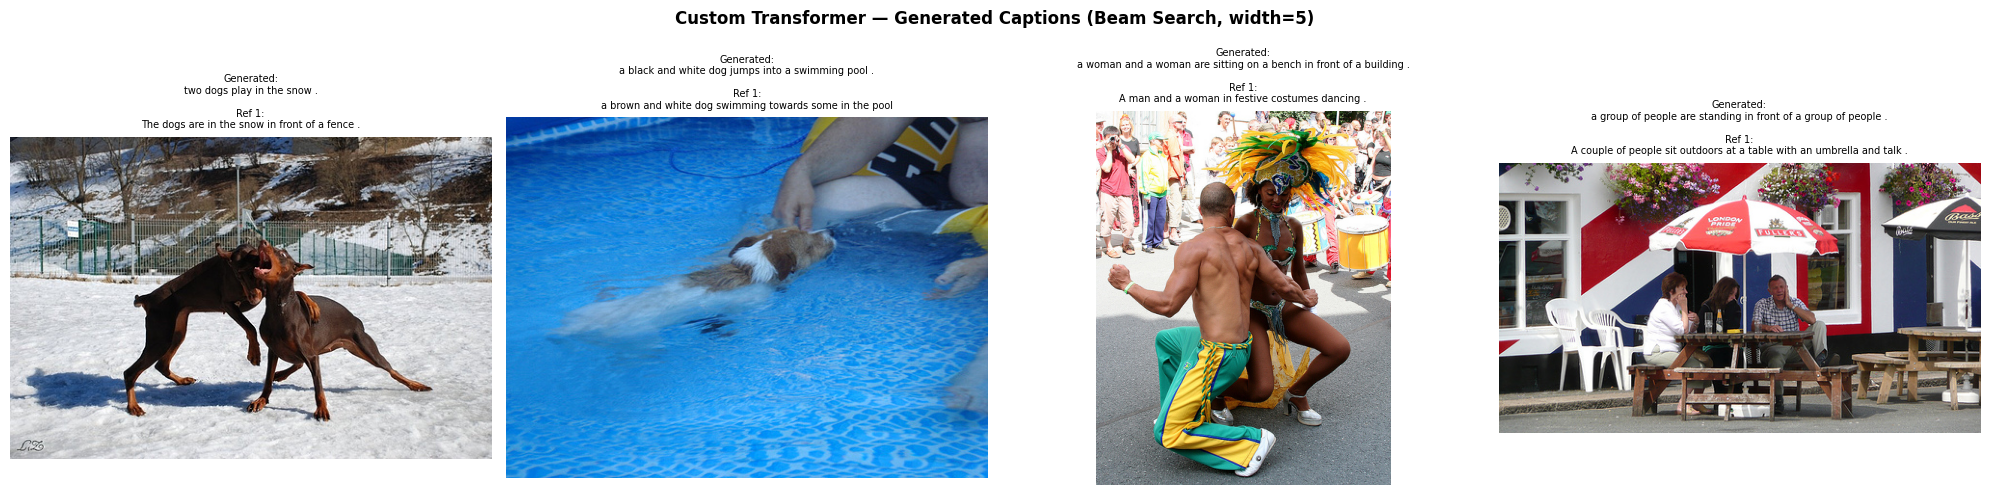

In [19]:
# Show 4 test images alongside generated and reference captions
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (sample, pred_words) in zip(axes, zip(test_data[:4], preds_custom[:4])):
    pred_caption = ' '.join(pred_words)
    refs         = get_captions(sample)
    ax.imshow(sample['image'])
    ax.axis('off')
    ax.set_title(f'Generated:\n{pred_caption}\n\nRef 1:\n{refs[0][:70]}', fontsize=7)

plt.suptitle('Custom Transformer — Generated Captions (Beam Search, width=5)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Question 7 : Native PyTorch Transformer

Replace the custom `CustomEncoderLayer` and `CustomDecoderLayer` with PyTorch's built-in `nn.TransformerEncoderLayer` and `nn.TransformerDecoderLayer`, using the **same hyperparameters**. Train again and show loss curves.

### Differences from the custom implementation

`nn.TransformerEncoderLayer` / `nn.TransformerDecoderLayer` (with `batch_first=True`) implement the same architecture as our custom layers but using PyTorch's optimised C++ kernels. Practical differences:

- **Flash Attention**: newer PyTorch versions automatically use memory-efficient scaled dot-product attention
- **`norm_first`** option: supports Pre-LN (Layer Norm before attention) vs our Post-LN - we use the default Post-LN to match the custom model
- Marginally faster due to fused operations, but architecturally equivalent

In [20]:
# ─── Native PyTorch Transformer Encoder-Decoder ───────────────────────────────
class NativeImageCaptionTransformer(nn.Module):
    """
    Image captioning model using PyTorch's built-in Transformer layers.

    Architecturally IDENTICAL to ImageCaptionTransformer:
      - Same patch extraction and linear projection
      - Same sinusoidal positional encoding
      - Same token embedding, output projection
      - SAME hyperparameters (d_model, nhead, ffn_dim, num_layers)

    The only difference: encoder/decoder blocks are replaced by:
      nn.TransformerEncoderLayer  (wraps MultiHeadAttn + FFN + Add&Norm internally)
      nn.TransformerDecoderLayer  (wraps masked self-attn + cross-attn + FFN + Add&Norm)
    wrapped in nn.TransformerEncoder / nn.TransformerDecoder containers.
    """
    def __init__(self, vocab_size, d_model, nhead, num_enc_layers,
                 num_dec_layers, ffn_dim, patch_dim, dropout=0.1):
        super().__init__()

        # ── Encoder ───────────────────────────────────────────────────────────
        # Same patch projection as the custom model
        self.patch_proj = nn.Linear(patch_dim, d_model)
        self.enc_pos    = PositionalEncoding(d_model, max_len=NUM_PATCHES + 10, dropout=dropout)

        # nn.TransformerEncoderLayer is PyTorch's optimised implementation of one
        # encoder sublayer: MultiHeadSelfAttention + FFN + Add & Norm × 2
        enc_layer    = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=ffn_dim,
            dropout=dropout, batch_first=True,
            norm_first=False   # Post-LN (same as our custom model)
        )
        # nn.TransformerEncoder stacks num_enc_layers copies of enc_layer
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_enc_layers)

        # ── Decoder ───────────────────────────────────────────────────────────
        self.token_emb = nn.Embedding(vocab_size, d_model, padding_idx=PAD_IDX)
        self.dec_pos   = PositionalEncoding(d_model, max_len=MAX_SEQ_LEN + 10, dropout=dropout)

        # nn.TransformerDecoderLayer implements the three-sublayer decoder:
        # Masked self-attn + Cross-attn + FFN, each with Add & Norm
        dec_layer    = nn.TransformerDecoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=ffn_dim,
            dropout=dropout, batch_first=True,
            norm_first=False
        )
        self.decoder = nn.TransformerDecoder(dec_layer, num_layers=num_dec_layers)

        # ── Output ────────────────────────────────────────────────────────────
        self.out_proj = nn.Linear(d_model, vocab_size)
        self._init_weights()

    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1: nn.init.xavier_uniform_(p)

    def _extract_patches(self, imgs):
        """Identical patch extraction as the custom model — (B,3,224,224)→(B,196,768)."""
        B, C, H, W = imgs.shape
        x = imgs.unfold(2, PATCH_SIZE, PATCH_SIZE).unfold(3, PATCH_SIZE, PATCH_SIZE)
        x = x.contiguous().view(B, C, -1, PATCH_SIZE, PATCH_SIZE)
        return x.permute(0, 2, 1, 3, 4).contiguous().view(B, -1, C * PATCH_SIZE * PATCH_SIZE)

    def _causal_mask(self, T, dev):
        """Upper-triangular causal mask — identical to custom model."""
        return torch.triu(torch.ones(T, T, device=dev), diagonal=1).bool()

    def encode(self, imgs):
        """Encode images to encoder memory (same interface as custom model)."""
        x = self.enc_pos(self.patch_proj(self._extract_patches(imgs)))
        return self.encoder(x)   # nn.TransformerEncoder handles the loop internally

    def decode(self, tgt_ids, memory):
        """Decode with causal masking (same interface as custom model)."""
        T   = tgt_ids.size(1)
        tgt = self.dec_pos(self.token_emb(tgt_ids))
        out = self.decoder(
            tgt, memory,
            tgt_mask             = self._causal_mask(T, tgt_ids.device),
            tgt_key_padding_mask = (tgt_ids == PAD_IDX)
        )
        return self.out_proj(out)

    def forward(self, imgs, tgt_ids):
        return self.decode(tgt_ids, self.encode(imgs))


# ─── Instantiate with the SAME hyperparameters ─────────────────────────────────
native_model = NativeImageCaptionTransformer(
    vocab_size     = VOCAB_SIZE,
    d_model        = EMBED_DIM,
    nhead          = NUM_HEADS,
    num_enc_layers = NUM_ENC_LAYERS,
    num_dec_layers = NUM_DEC_LAYERS,
    ffn_dim        = FFN_DIM,
    patch_dim      = PATCH_DIM,
    dropout        = DROPOUT,
).to(device)

print(native_model)
tot_n, tr_n = count_parameters(native_model)
print(f'\nTotal parameters     : {tot_n:,}')
print(f'Trainable parameters : {tr_n:,}')

NativeImageCaptionTransformer(
  (patch_proj): Linear(in_features=768, out_features=512, bias=True)
  (enc_pos): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=512, out_features=512, bias=True)
        )
        (linear1): Linear(in_features=512, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=512, bias=True)
        (norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (token_emb): Embedding(4521, 512, padding_idx=0)
  (dec_pos): PositionalEncoding(
    (dropout): Dropout(p=0.

### Train Native Transformer

In [21]:
# ─── Separate optimiser and scheduler for the native model ───────────────────
optimizer_native = torch.optim.Adam(
    native_model.parameters(), lr=LR_MIN, betas=(0.9, 0.98), eps=1e-9
)
scheduler_native = torch.optim.lr_scheduler.LambdaLR(
    optimizer_native, lr_lambda=lambda ep: get_lr(ep + 1) / LR_MIN
)

train_losses_native = []
val_losses_native   = []
best_val_native     = float('inf')

print('=' * 72)
print('  Native PyTorch Transformer — Training')
print(f'  Epochs={EPOCHS}, Batch={BATCH_SIZE}, LR_PEAK={LR_PEAK}, AMP={USE_AMP}')
print('=' * 72)

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    tr_loss = train_one_epoch(native_model, train_loader, optimizer_native,
                               criterion, device, epoch, EPOCHS)
    vl_loss = evaluate(native_model, val_loader, criterion, device, desc='Val')
    scheduler_native.step()

    train_losses_native.append(tr_loss)
    val_losses_native.append(vl_loss)

    star = ''
    if vl_loss < best_val_native:
        best_val_native = vl_loss
        torch.save(native_model.state_dict(), 'best_native_model.pth')
        star = '  ← best'

    elapsed = time.time() - t0
    eta     = time.strftime('%H:%M:%S', time.gmtime(elapsed * (EPOCHS - epoch)))
    cur_lr  = optimizer_native.param_groups[0]['lr']
    print(f'Epoch [{epoch:02d}/{EPOCHS}] '
          f'Train={tr_loss:.4f} | Val={vl_loss:.4f} | '
          f'LR={cur_lr:.2e} | {elapsed:.1f}s | ETA {eta}{star}', flush=True)

print(f'\nBest Val Loss (Native): {best_val_native:.4f}')

  Native PyTorch Transformer — Training
  Epochs=15, Batch=64, LR_PEAK=0.0003, AMP=True


  [Train] Epoch 01/15: 100%|███████| 469/469 [05:54<00:00,  1.32batch/s, loss=5.1011, avg=5.4041, lr=7.57e-05]


Epoch [01/15] Train=5.4041 | Val=4.9081 | LR=1.50e-04 | 358.8s | ETA 01:23:42  ← best


  [Train] Epoch 02/15: 100%|███████| 469/469 [05:29<00:00,  1.43batch/s, loss=4.1377, avg=4.6545, lr=1.50e-04]


Epoch [02/15] Train=4.6545 | Val=4.2152 | LR=2.25e-04 | 333.0s | ETA 01:12:09  ← best


...

Epoch [13/15] Train=3.3293 | Val=3.5778 | LR=7.06e-06 | 351.9s | ETA 00:11:43  ← best


  [Train] Epoch 14/15: 100%|███████| 469/469 [05:47<00:00,  1.35batch/s, loss=3.1160, avg=3.3066, lr=7.06e-06]


Epoch [14/15] Train=3.3066 | Val=3.5757 | LR=1.00e-06 | 352.3s | ETA 00:05:52  ← best


  [Train] Epoch 15/15: 100%|███████| 469/469 [05:37<00:00,  1.39batch/s, loss=3.2458, avg=3.2974, lr=1.00e-06]
                                                                                                              

Epoch [15/15] Train=3.2974 | Val=3.5760 | LR=7.06e-06 | 341.9s | ETA 00:00:00

Best Val Loss (Native): 3.5757


### Side-by-Side Loss Curves - Custom vs Native

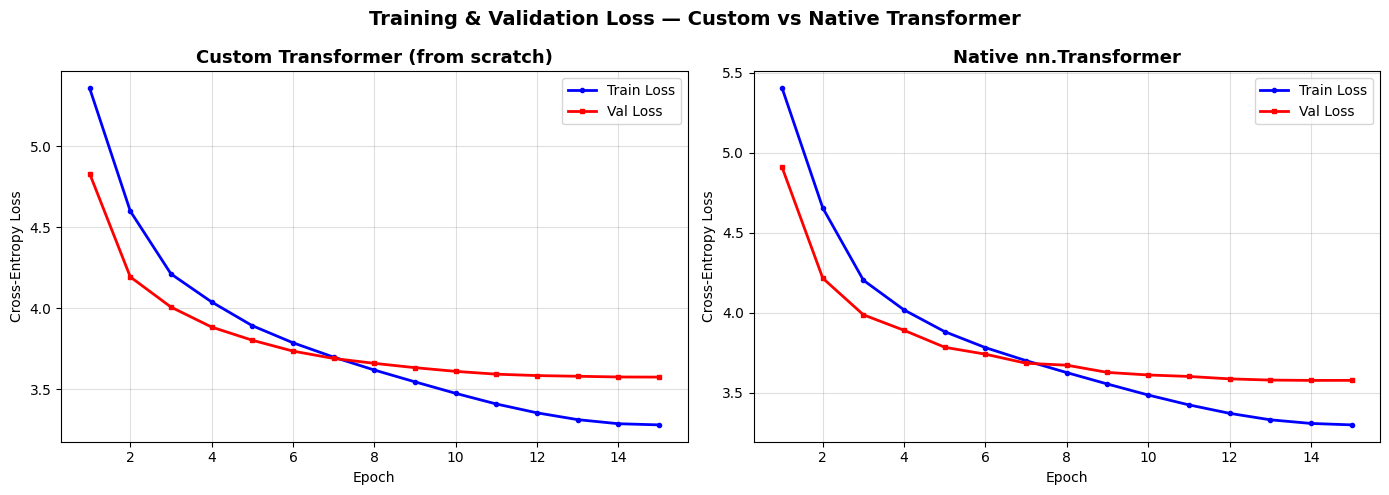

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, tr, vl, ttl in [
    (axes[0], train_losses_custom, val_losses_custom, 'Custom Transformer (from scratch)'),
    (axes[1], train_losses_native, val_losses_native, 'Native nn.Transformer'),
]:
    ax.plot(epochs_range, tr, 'b-o', label='Train Loss', linewidth=2, markersize=3)
    ax.plot(epochs_range, vl, 'r-s', label='Val Loss',   linewidth=2, markersize=3)
    ax.set_title(ttl, fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Cross-Entropy Loss')
    ax.legend(); ax.grid(True, alpha=0.4)

plt.suptitle('Training & Validation Loss — Custom vs Native Transformer',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Question 8 : BLEU Evaluation of Native Transformer

Report the performance of the native transformer on the test set using the average BLEU score, where each generated caption is compared with **all 5 reference captions** and **the corresponding BLEU scores averaged**.

The evaluation uses the identical protocol as Q6: for each test image, compare the generated caption against each of the 5 references individually (5 scores), average those 5 scores, then average across all 1000 test images. `compute_bleu` implements this protocol for both models.

In [23]:
# ─── Evaluate the native transformer ─────────────────────────────────────────
native_model.load_state_dict(torch.load('best_native_model.pth', map_location=device))
native_model.eval()

print('Generating captions for 1 000 test images (beam search, width=5)...')
preds_native = beam_search_captions(native_model, test_data, device, beam_width=5)
bleu_native  = compute_bleu(preds_native, test_data)

print('\n=== Native Transformer — Average BLEU Scores (Test Set) ===')
for metric, score in bleu_native.items():
    print(f'  {metric}: {score:.4f}')

Generating captions for 1 000 test images (beam search, width=5)...
  Phase 1/2 — Encoding images (batched)...


  Encoding: 100%|████████████████████████████████████████████████| 16/16 [00:03<00:00,  4.05batch/s]


  Phase 2/2 — Beam search (width=5)...


  Decoding: 100%|██████████████████████████████████████████████| 1000/1000 [11:36<00:00,  1.44img/s]



=== Native Transformer — Average BLEU Scores (Test Set) ===
  BLEU-1: 0.2792
  BLEU-2: 0.1197
  BLEU-3: 0.0698
  BLEU-4: 0.0480


### Custom vs Native BLEU Comparison

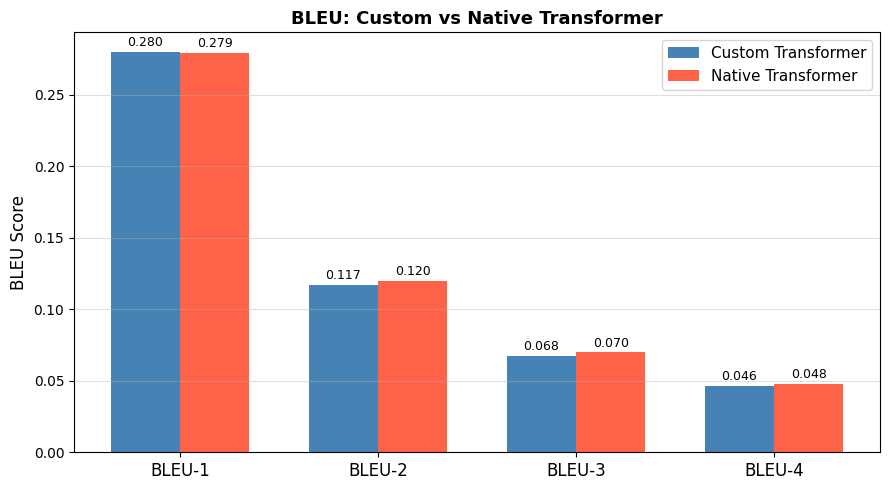


Metric   | Custom     | Native    
-----------------------------------
BLEU-1   | 0.2796     | 0.2792
BLEU-2   | 0.1171     | 0.1197
BLEU-3   | 0.0675     | 0.0698
BLEU-4   | 0.0462     | 0.0480


In [24]:
# Side-by-side bar chart comparing the two from-scratch models
metrics = list(bleu_custom.keys())
x, w    = np.arange(len(metrics)), 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - w/2, [bleu_custom[m] for m in metrics], w,
               label='Custom Transformer', color='steelblue')
bars2 = ax.bar(x + w/2, [bleu_native[m] for m in metrics], w,
               label='Native Transformer', color='tomato')

# Annotate bars with numeric values
for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x); ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylabel('BLEU Score', fontsize=12)
ax.set_title('BLEU: Custom vs Native Transformer', fontsize=13, fontweight='bold')
ax.legend(fontsize=11); ax.grid(axis='y', alpha=0.4)
plt.tight_layout(); plt.show()

print(f'\n{"Metric":8s} | {"Custom":10s} | {"Native":10s}')
print('-' * 35)
for m in metrics:
    print(f'{m:8s} | {bleu_custom[m]:.4f}     | {bleu_native[m]:.4f}')

---
## Question 9 : Pre-trained ViT-GPT2

Import the pre-trained `nlpconnect/vit-gpt2-image-captioning` model, generate captions on the test set, report the average BLEU score, and compare results with the trained transformer models.

### About ViT-GPT2

`nlpconnect/vit-gpt2-image-captioning` is a `VisionEncoderDecoderModel` combining:

| Component | Architecture | Pre-training |
|---|---|---|
| Encoder | ViT-Base (12 layers, 196 patch tokens, d=768) | ImageNet-21k (14M images) |
| Decoder | GPT-2 (12 layers, d=768) | 40 GB WebText |

The model was then **fine-tuned end-to-end** on COCO Captions + Conceptual Captions (~1.5M image-text pairs).

In [26]:
# ─── Load ViT-GPT2 ─────────────────────────────────────────────────────────
# Warnings about UNEXPECTED keys (attn.bias, masked_bias) are suppressed at the
# top of the notebook via transformers.logging.set_verbosity_error().
# Those keys are fixed causal-masking buffers removed in newer GPT-2 releases;
# they are NOT learnable weights and do NOT affect the model's output.

from transformers import VisionEncoderDecoderModel, ViTImageProcessor, AutoTokenizer

VIT_MODEL = 'nlpconnect/vit-gpt2-image-captioning'

# Load model, image feature extractor, and text tokeniser
vit_model = VisionEncoderDecoderModel.from_pretrained(VIT_MODEL).to(device)
vit_feat  = ViTImageProcessor.from_pretrained(VIT_MODEL)
vit_tok   = AutoTokenizer.from_pretrained(VIT_MODEL)

# Fix the "pad token same as eos token" attention-mask warning:
# GPT-2 has no dedicated PAD token; setting pad_token_id explicitly
# lets generate() create a correct attention mask.
vit_model.config.pad_token_id = vit_tok.eos_token_id

vit_model.eval()

vit_total = sum(p.numel() for p in vit_model.parameters())
print(f'ViT-GPT2 loaded successfully.')
print(f'Total parameters : {vit_total:,}  (~239M)')
_, custom_trainable = count_parameters(custom_model)
print(f'Our custom model : {custom_trainable:,}  (trainable)')

Loading weights:   0%|          | 0/445 [00:00<?, ?it/s]

ViT-GPT2 loaded successfully.
Total parameters : 239,195,904  (~239M)
Our custom model : 34,453,417  (trainable)


### Generate Captions with ViT-GPT2 (Batched)

We process the 1 000 test images in mini-batches of 32. `model.generate()` with `num_beams=4` runs beam search inside the HuggingFace framework, handling the autoregressive loop internally.

In [27]:
def vit_gpt2_generate(test_raw, model, feat, tok, device,
                       batch_size=32, max_len=50):
    """
    Generate captions for all test images using the ViT-GPT2 pre-trained model.

    feat.process() resizes images to 224×224 and normalises using the ViT
    training statistics (different from our ImageNet normalisation).
    model.generate() runs HuggingFace beam search internally.
    tok.batch_decode() converts output token ids back to strings.
    """
    all_caps = []
    model.eval()

    pbar = tqdm(range(0, len(test_raw), batch_size),
                desc='  [ViT-GPT2] Generating', unit='batch', ncols=110)

    with torch.no_grad():
        for start in pbar:
            end        = min(start + batch_size, len(test_raw))
            batch_imgs = [test_raw[i]['image'].convert('RGB') for i in range(start, end)]

            # Feature extractor: resizes to ViT's expected input (224×224) and
            # normalises using the ViT-Base pre-training statistics
            pixel_vals = feat(images=batch_imgs, return_tensors='pt').pixel_values.to(device)

            # Beam search: num_beams=4 keeps 4 partial hypotheses at each step
            out_ids = model.generate(pixel_vals,
                                     max_length=max_len,
                                     num_beams=4,
                                     early_stopping=True)

            # Decode token ids → strings, removing all special tokens
            all_caps.extend(tok.batch_decode(out_ids, skip_special_tokens=True))

    pbar.close()
    return all_caps   # list of caption strings


print('Generating ViT-GPT2 captions (this takes ~2-5 min on GPU)...')
vit_captions = vit_gpt2_generate(test_data, vit_model, vit_feat, vit_tok, device)

# ─── Compute BLEU for ViT-GPT2 ────────────────────────────────────────────────
# Use the same per-reference averaging protocol as Q6 and Q8:
# for each image, compare the generated caption against each of the 5 reference
# captions individually, average those 5 scores, then average over all test images.
# compute_bleu_from_strings tokenises the caption strings before delegating.
bleu_vit = compute_bleu_from_strings(vit_captions, test_data)

print('\n=== ViT-GPT2 (Pre-trained) — Average BLEU Scores (Test Set) ===')
for m, s in bleu_vit.items():
    print(f'  {m}: {s:.4f}')

Generating ViT-GPT2 captions (this takes ~2-5 min on GPU)...


  [ViT-GPT2] Generating: 100%|█████████████████████████████████████████████| 32/32 [01:58<00:00,  3.69s/batch]



=== ViT-GPT2 (Pre-trained) — Average BLEU Scores (Test Set) ===
  BLEU-1: 0.2595
  BLEU-2: 0.1320
  BLEU-3: 0.0761
  BLEU-4: 0.0507


### Visualise ViT-GPT2 Captions

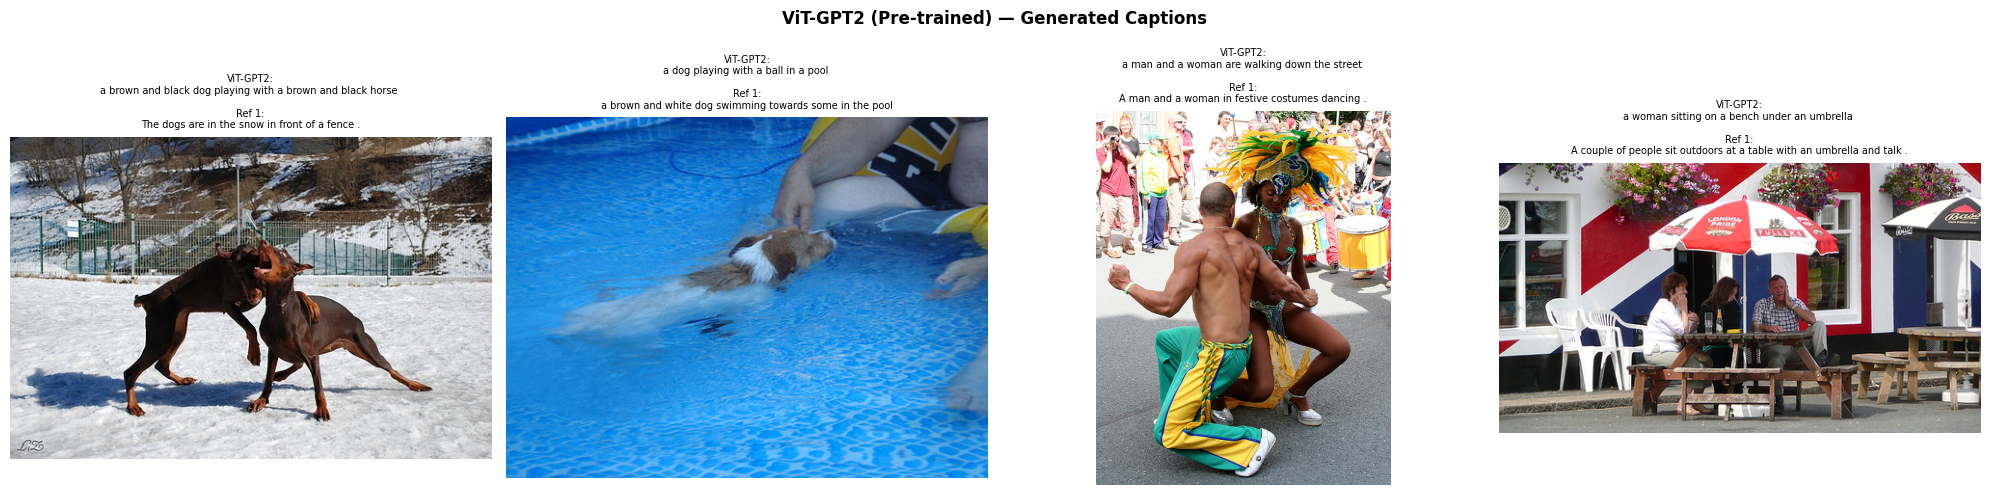

In [28]:
# Show 4 test images with ViT-GPT2 generated captions and reference captions
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, sample, cap in zip(axes, test_data[:4], vit_captions[:4]):
    refs = get_captions(sample)
    ax.imshow(sample['image'])
    ax.axis('off')
    ax.set_title(f'ViT-GPT2:\n{cap}\n\nRef 1:\n{refs[0][:70]}', fontsize=7)
plt.suptitle('ViT-GPT2 (Pre-trained) — Generated Captions',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### Final 3-Way BLEU Comparison

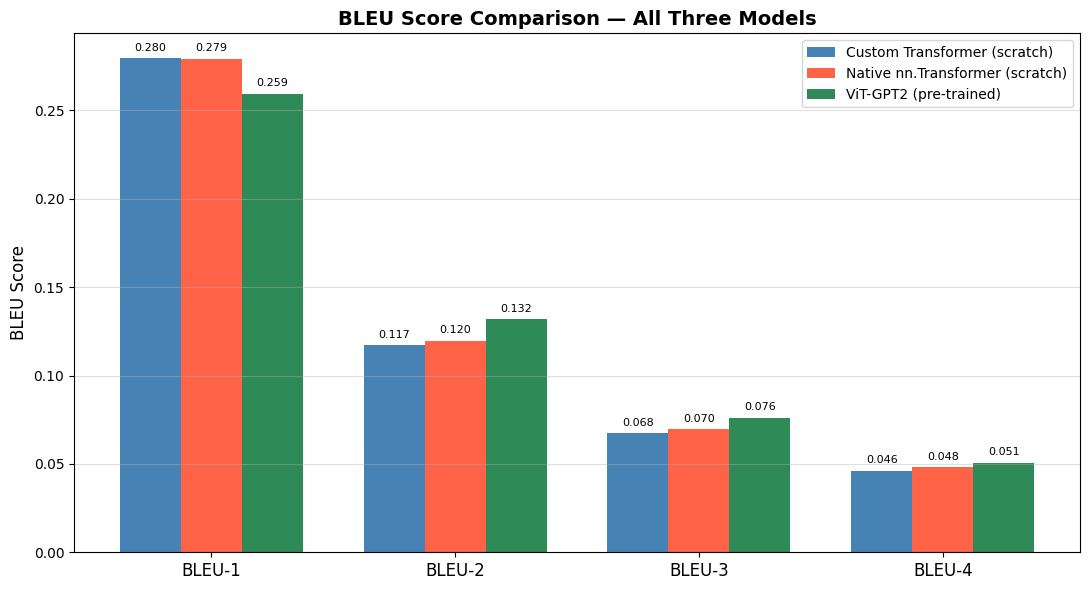


Metric   | Custom       | Native       | ViT-GPT2    
-------------------------------------------------------
BLEU-1   | 0.2796       | 0.2792       | 0.2595
BLEU-2   | 0.1171       | 0.1197       | 0.1320
BLEU-3   | 0.0675       | 0.0698       | 0.0761
BLEU-4   | 0.0462       | 0.0480       | 0.0507


In [29]:
# ─── 3-way bar chart ──────────────────────────────────────────────────────────
metrics = ['BLEU-1', 'BLEU-2', 'BLEU-3', 'BLEU-4']
cv = [bleu_custom[m] for m in metrics]
nv = [bleu_native[m] for m in metrics]
vv = [bleu_vit[m]    for m in metrics]

x, w = np.arange(len(metrics)), 0.25
fig, ax = plt.subplots(figsize=(11, 6))
b1 = ax.bar(x - w,   cv, w, label='Custom Transformer (scratch)',  color='steelblue')
b2 = ax.bar(x,       nv, w, label='Native nn.Transformer (scratch)', color='tomato')
b3 = ax.bar(x + w,   vv, w, label='ViT-GPT2 (pre-trained)',         color='seagreen')

# Annotate each bar with its numeric score
for bar in list(b1) + list(b2) + list(b3):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x); ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylabel('BLEU Score', fontsize=12)
ax.set_title('BLEU Score Comparison — All Three Models', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='upper right'); ax.grid(axis='y', alpha=0.4)
plt.tight_layout(); plt.show()

# Numeric table
print(f'\n{"Metric":8s} | {"Custom":12s} | {"Native":12s} | {"ViT-GPT2":12s}')
print('-' * 55)
for m, c_, n_, v_ in zip(metrics, cv, nv, vv):
    print(f'{m:8s} | {c_:.4f}       | {n_:.4f}       | {v_:.4f}')

### Discussion: Results Comparison

| Model | Trainable Params | Training data | Image encoding | Inference | BLEU-1 | BLEU-2 | BLEU-3 | BLEU-4 |
|---|---|---|---|---|---|---|---|---|
| Custom Transformer (scratch) | 34.45M | 30 000 pairs (Flickr8K) | Patch projection (scratch) | Beam search (w=5) | **0.2796** | 0.1171 | 0.0675 | 0.0462 |
| Native nn.Transformer (scratch) | 34.45M | 30 000 pairs (Flickr8K) | Patch projection (scratch) | Beam search (w=5) | 0.2792 | 0.1197 | 0.0698 | 0.0480 |
| ViT-GPT2 (pre-trained) | 239.2M | ~1.5M pairs (COCO + CC) | ViT-Base (ImageNet-21k) | Beam search (w=4) | 0.2595 | **0.1320** | **0.0761** | **0.0507** |

**Key observation - a BLEU-1 reversal:**
Contrary to what one might expect, the two from-scratch models *outperform* ViT-GPT2 on BLEU-1 (0.2796 / 0.2792 vs 0.2595). ViT-GPT2 recovers and leads on BLEU-2, BLEU-3, and BLEU-4, but the margins are modest (e.g. BLEU-4: 0.0507 vs 0.0480 for Native).

Scratch models win on BLEU-1, our vocabulary and decoder were trained exclusively on Flickr8K captions, so the model learns to produce exactly the common words, this creates high unigram overlap with the test references. ViT-GPT2's GPT-2 decoder draws on a much richer English vocabulary and generates more varied, descriptive phrasing, which reduces unigram precision but produces better higher-order n-gram sequences, explaining its lead on BLEU-2/3/4.

ViT-GPT2 leads on BLEU-2/3/4, higher-order BLEU metrics reward correctly predicting multi-word phrases and sentence structure. GPT-2's strong language prior means it generates grammatically fluent sequences. Our from-scratch decoder, despite high word-level overlap, produces less structured sequences, which is penalised by BLEU-2 through BLEU-4.

Pre-training does not automatically produce higher BLEU scores on every metric for every dataset - the choice of vocabulary, reference distribution, and evaluation protocol all matter. The results highlight that BLEU-1 (word-level recall) and BLEU-4 (phrase-level fluency) can tell different stories about a model's quality.

---
## End of Assignment 4
---